In [6]:
from pathlib import Path

import xarray as xr
import pandas as pd
import numpy as np

# Path to the composite Zarr
COMPOSITE_ZARR = Path(
    #"/lustre/utmp/std/MLCAST_radar_data/events/emilia/composite/emilia_sri_composite.zarr"
    "/lustre/utmp/std/MLCAST_radar_data/events/emilia/individual/SEV/borrasca_emilia_sri_SEV_20251212_20251215.zarr"
)

def detect_zarr_format(path: Path) -> int:
    return 3 if (path / "zarr.json").exists() else 2

zarr_format = detect_zarr_format(COMPOSITE_ZARR)

ds = xr.open_zarr(
    COMPOSITE_ZARR,
    consolidated=False,
    zarr_format=zarr_format,
    chunks={"time": 1},
)

print(ds)
print("\nZarr format:", zarr_format)
print("Variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))
print("Sizes:", dict(ds.sizes))

if "time" in ds.coords:
    time_index = pd.DatetimeIndex(ds["time"].values)
    print("\nNumber of timesteps:", len(time_index))
    print("Number of unique timesteps:", len(time_index.unique()))
    print("First time:", time_index.min() if len(time_index) else None)
    print("Last time:", time_index.max() if len(time_index) else None)
    print("First 10 times:")
    print(time_index[:10])

<xarray.Dataset> Size: 569MB
Dimensions:        (time: 574, y: 497, x: 497)
Coordinates:
  * time           (time) datetime64[ns] 5kB 2025-12-12 ... 2025-12-15T23:40:00
  * y              (y) float64 4kB 3.929e+06 3.93e+06 ... 4.424e+06 4.425e+06
  * x              (x) float64 4kB -4.213e+04 -4.113e+04 ... 4.533e+05 4.543e+05
    lat            (y, x) float32 988kB dask.array<chunksize=(497, 497), meta=np.ndarray>
    lon            (y, x) float32 988kB dask.array<chunksize=(497, 497), meta=np.ndarray>
Data variables:
    rainfall_rate  (time, y, x) float32 567MB dask.array<chunksize=(1, 497, 497), meta=np.ndarray>
    spatial_ref    int32 4B ...
Attributes: (12/16)
    CDI:                               Climate Data Interface version 1.8.2 (...
    history:                           Converted from NetCDF radar files to Zarr
    Conventions:                       CF-1.10
    GDAL:                              GDAL 2.2.3, released 2017/11/20
    CDO:                               Climat

In [7]:
import numpy as np
import pandas as pd

print(ds)

for coord in ["x", "y", "lat", "lon"]:
    if coord in ds:
        arr = ds[coord].values
        print("\n" + "=" * 80)
        print(coord)
        print("shape:", arr.shape)
        print("dtype:", arr.dtype)
        print("finite:", np.isfinite(arr).sum(), "/", arr.size)
        print("nan:", np.isnan(arr).sum())
        print("min:", np.nanmin(arr) if np.isfinite(arr).any() else None)
        print("max:", np.nanmax(arr) if np.isfinite(arr).any() else None)

        if arr.ndim == 1:
            print("first 10:", arr[:10])
            print("last 10:", arr[-10:])
        elif arr.ndim == 2:
            print("top-left block:")
            print(arr[:3, :3])
            print("bottom-right block:")
            print(arr[-3:, -3:])

print("\nTime diagnostics")
time_index = pd.DatetimeIndex(ds["time"].values)
print("time size:", len(time_index))
print("unique time size:", len(time_index.unique()))
print("first 20 times:", time_index[:20])
print("duplicated:", time_index.duplicated().sum())

<xarray.Dataset> Size: 569MB
Dimensions:        (time: 574, y: 497, x: 497)
Coordinates:
  * time           (time) datetime64[ns] 5kB 2025-12-12 ... 2025-12-15T23:40:00
  * y              (y) float64 4kB 3.929e+06 3.93e+06 ... 4.424e+06 4.425e+06
  * x              (x) float64 4kB -4.213e+04 -4.113e+04 ... 4.533e+05 4.543e+05
    lat            (y, x) float32 988kB dask.array<chunksize=(497, 497), meta=np.ndarray>
    lon            (y, x) float32 988kB dask.array<chunksize=(497, 497), meta=np.ndarray>
Data variables:
    rainfall_rate  (time, y, x) float32 567MB dask.array<chunksize=(1, 497, 497), meta=np.ndarray>
    spatial_ref    int32 4B ...
Attributes: (12/16)
    CDI:                               Climate Data Interface version 1.8.2 (...
    history:                           Converted from NetCDF radar files to Zarr
    Conventions:                       CF-1.10
    GDAL:                              GDAL 2.2.3, released 2017/11/20
    CDO:                               Climat

Requested time: 2025-12-14 12:00:00
Selected time: 2025-12-14 12:00:00
Variable: rainfall_rate
Units: unknown
Extent: [-42629.20804003591, 454810.2971890865, 3928020.5802826704, 4425460.085511793]


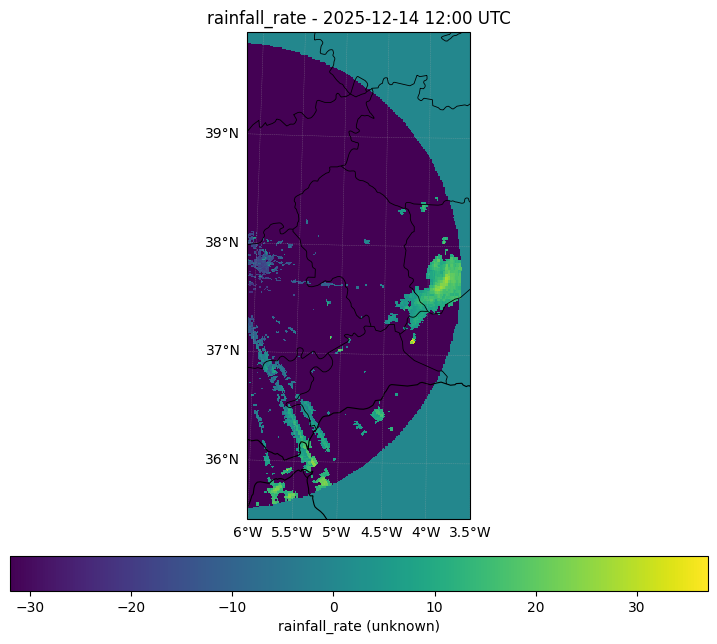

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import numpy as np

VAR_NAME = "rainfall_rate"      # or "reflectivity_dbz"
TARGET_TIME = "2025-12-14T12:00:00"

# --- Select nearest time robustly, even with duplicated times ---
time_index = pd.DatetimeIndex(ds["time"].values)
unique_times = pd.DatetimeIndex(sorted(time_index.unique()))

target = pd.Timestamp(TARGET_TIME)
nearest_unique_time = unique_times[np.argmin(np.abs(unique_times - target))]

da_all = ds[VAR_NAME].sel(time=nearest_unique_time)
da = da_all.isel(time=0) if "time" in da_all.dims else da_all

print("Requested time:", target)
print("Selected time:", nearest_unique_time)
print("Variable:", VAR_NAME)
print("Units:", da.attrs.get("units", ""))

# --- Clean x/y coordinates ---
x = ds["x"].values.astype(float)
y = ds["y"].values.astype(float)

x_finite = x[np.isfinite(x)]
y_finite = y[np.isfinite(y)]

if len(x_finite) == 0 or len(y_finite) == 0:
    raise ValueError("x/y coordinates contain no finite values.")

dx = float(np.nanmedian(np.diff(x_finite)))
dy = float(np.nanmedian(np.diff(y_finite)))

extent = [
    float(np.nanmin(x_finite) - dx / 2),
    float(np.nanmax(x_finite) + dx / 2),
    float(np.nanmin(y_finite) - dy / 2),
    float(np.nanmax(y_finite) + dy / 2),
]

print("Extent:", extent)

# --- Plot ---
data_crs = ccrs.epsg(25830)

fig = plt.figure(figsize=(9, 8))
ax = plt.axes(projection=data_crs)

mesh = ax.imshow(
    da.values,
    origin="lower",
    extent=extent,
    transform=data_crs,
    interpolation="nearest",
    cmap="viridis",
)

ax.set_extent(extent, crs=data_crs)

ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.6)

provinces = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none",
)

ax.add_feature(
    provinces,
    edgecolor="black",
    linewidth=0.6,
    zorder=4,
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    alpha=0.5,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.06)
cbar.set_label(f"{VAR_NAME} ({da.attrs.get('units', '')})")

ax.set_title(
    f"{VAR_NAME} - {nearest_unique_time.strftime('%Y-%m-%d %H:%M UTC')}"
)

plt.show()